In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Embedding, Input, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载数据
train_df = pd.read_excel('E:/Fakenews Detection/Dataest_2.0/Fakenews_train.xlsx', engine='openpyxl')
test_df = pd.read_excel('E:/Fakenews Detection/Dataest_2.0/Fakenews_test.xlsx', engine='openpyxl')

# 提取文本和标签
X_train_texts = train_df['text'].values
y_train = train_df['label'].values
X_test_texts = test_df['text'].values
y_test = test_df['label'].values

# 预处理文本数据
max_words = 10000
max_len = 150

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_texts)
X_train_sequences = tokenizer.texts_to_sequences(X_train_texts)
X_test_sequences = tokenizer.texts_to_sequences(X_test_texts)

X_train = pad_sequences(X_train_sequences, maxlen=max_len)
X_test = pad_sequences(X_test_sequences, maxlen=max_len)

# 将标签转换为浮点数
y_train = y_train.astype(float)
y_test = y_test.astype(float)

# 构造基础模型（确保嵌入层维度正确）
def create_embedding_model():
    text_input = Input(shape=(150,), dtype=tf.int32, name='text_input')

    text_embedding = Embedding(input_dim=10000, output_dim=64, input_length=150, name='embedding')(text_input)
    text_flatten = Flatten(name='flatten')(text_embedding)

    x = Dense(64, activation='relu', name='dense_1')(text_flatten)
    output = Dense(1, activation='sigmoid', name='dense_2')(x)

    model = Model(inputs=text_input, outputs=output)
    return model

# 创建中间模型
def create_middle_model(base_model):
    text_input = base_model.get_layer(name='text_input').input
    embedding_output = base_model.get_layer(name='embedding').output
    middle_model = Model(inputs=text_input, outputs=embedding_output)
    return middle_model

# 动态扰动函数
def calculate_dynamic_replacements(text_length):
    return max(1, text_length // 20)

# 生成对抗样本时的维度处理
def generate_adversarial_samples(model, middle_model, X_sample, y_sample, epsilon=0.1, batch_size=128):
    num_samples = X_sample.shape[0]
    adversarial_samples = []

    for i in range(0, num_samples, batch_size):
        start = i
        end = min(i + batch_size, num_samples)

        X_batch = X_sample[start:end]
        y_batch = y_sample[start:end]

        X_sample_tensor = tf.convert_to_tensor(X_batch, dtype=tf.int32)
        y_sample_tensor = tf.convert_to_tensor(y_batch, dtype=tf.float32)

        with tf.GradientTape() as tape:
            embed_output = middle_model(X_sample_tensor)
            print("embed_output shape:", embed_output.shape)  # 应输出 (128, 150, 64)
            tape.watch(embed_output)
            flatten_output = tf.reshape(embed_output, [-1, 150 * 64])
            print("flatten_output shape:", flatten_output.shape)  # 应输出 (128, 9600)

            layer_input = flatten_output
            for i, layer in enumerate(model.layers[1:]):
                print(f"Layer {i}: {layer.name}, Input shape: {layer_input.shape}")
                layer_input = layer(layer_input)
                print(f"Layer {i}: {layer.name}, Output shape: {layer_input.shape}")
            predictions = layer_input

            loss = BinaryCrossentropy()(y_sample_tensor, predictions)

        gradients = tape.gradient(loss, embed_output)
        perturbations = epsilon * tf.sign(gradients)

        dynamic_epsilon = calculate_dynamic_replacements(X_batch.shape[1])
        embed_output_adv = embed_output + dynamic_epsilon * perturbations

        batch_adversarial_samples = tf.argmax(embed_output_adv, axis=-1).numpy()
        adversarial_samples.append(batch_adversarial_samples)

        del embed_output, flatten_output, layer_input, predictions, loss, gradients, perturbations, embed_output_adv
        tf.keras.backend.clear_session()

    return np.concatenate(adversarial_samples, axis=0)

# 改进的加权平均权重方法
class WeightedAveragingCallback(tf.keras.callbacks.Callback):
    def __init__(self, model, beta=0.1, gamma=0.9, lambda_reg=0.01, validation_data=None):
        super().__init__()
        self.beta = beta
        self.gamma = gamma
        self.lambda_reg = lambda_reg
        self.model_weights = model.get_weights()
        self.epoch_count = 0
        self.best_acc = -float('inf')
        self.best_weights = None
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_count == 0:
            self.model_weights = self.model.get_weights()
        else:
            new_weights = self.model.get_weights()
            with tf.GradientTape() as tape:
                predictions = self.model(self.model.input)
                loss = self.model.compiled_loss(y_true=self.model.targets, y_pred=predictions)
            grads = tape.gradient(loss, self.model.trainable_weights)

            new_weights = []
            for i, (weight, grad) in enumerate(zip(self.model_weights, grads)):
                loss_contribution = tf.reduce_sum(tf.abs(grad))
                weight_update = weight - self.beta * loss_contribution * grad - self.lambda_reg * weight
                new_weights.append(weight_update)

            self.model_weights = [(1 - self.beta) * w_new + self.beta * w_old for w_old, w_new in zip(self.model_weights, new_weights)]
            self.beta = self.gamma * self.beta

        # 仅计算准确率
        if self.validation_data:
            X_val, y_val = self.validation_data
            y_pred = (self.model.predict(X_val) > 0.5).astype(int)
            current_acc = accuracy_score(y_val, y_pred)

            if current_acc > self.best_acc:
                self.best_acc = current_acc
                self.best_weights = self.model.get_weights()

        self.epoch_count += 1

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
        else:
            self.model.set_weights(self.model_weights)

# 计算额外的评估指标
def evaluate_model(model, X, y_true):
    y_pred = (model.predict(X) > 0.5).astype(int)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return precision, recall, f1

# 聚合对抗性训练数据进行训练
def train_and_evaluate_adv(model, middle_model, X_train, y_train, X_test, y_test, epochs=10, epsilon=0.1):
    history_logs = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    precision_logs = {'train': [], 'val': []}
    recall_logs = {'train': [], 'val': []}
    f1_logs = {'train': [], 'val': []}

    model.compile(optimizer=Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=['accuracy'])
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        # 生成对抗样本
        X_adv_samples = generate_adversarial_samples(model, middle_model, X_train, y_train, epsilon)

        # 合并对抗数据
        X_combined = np.concatenate((X_train, X_adv_samples), axis=0)
        y_combined = np.concatenate((y_train, y_train), axis=0)

        averaging_callback = WeightedAveragingCallback(model)
        history = model.fit(X_combined, y_combined, epochs=1, batch_size=16, validation_split=0.2, verbose=1, callbacks=[averaging_callback])

        for key in history_logs:
            history_logs[key].append(history.history[key][0])

        # 计算训练和验证集上的精确率、召回率和F1分数
        val_split_idx = len(X_combined) * 80 // 100
        precision_train, recall_train, f1_train = evaluate_model(model, X_combined[:val_split_idx], y_combined[:val_split_idx])
        precision_val, recall_val, f1_val = evaluate_model(model, X_combined[val_split_idx:], y_combined[val_split_idx:])

        precision_logs['train'].append(precision_train)
        recall_logs['train'].append(recall_train)
        f1_logs['train'].append(f1_train)
        precision_logs['val'].append(precision_val)
        recall_logs['val'].append(recall_val)
        f1_logs['val'].append(f1_val)

    # 在原始测试集上进行评估（不结合对抗样本）
    _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'对抗训练模型在原始测试集上的准确率: {accuracy:.4f}')

    precision, recall, f1 = evaluate_model(model, X_test, y_test)
    print(f'对抗训练模型在原始测试集上的精确率: {precision:.4f}, 召回率: {recall:.4f}, F1分数: {f1:.4f}')

    # 生成并评估对抗测试数据
    X_test_adv_samples = generate_adversarial_samples(model, middle_model, X_test, y_test, epsilon)

    _, accuracy_adv = model.evaluate(X_test_adv_samples, y_test, verbose=0)
    print(f'对抗训练模型在对抗测试集上的准确率: {accuracy_adv:.4f}')

    precision_adv, recall_adv, f1_adv = evaluate_model(model, X_test_adv_samples, y_test)
    print(f'对抗训练模型在对抗测试集上的精确率: {precision_adv:.4f}, 召回率: {recall_adv:.4f}, F1分数: {f1_adv:.4f}')

    return model, history_logs, precision_logs, recall_logs, f1_logs

# 创建并训练常规模型
standard_model = create_embedding_model()
standard_model.compile(optimizer=Adam(learning_rate=1e-4), loss=BinaryCrossentropy(), metrics=['accuracy'])
history = standard_model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2, verbose=1)

# 在原始测试集上评估常规模型
_, accuracy_standard = standard_model.evaluate(X_test, y_test, verbose=0)
print(f'常规模型在原始测试集上的准确率: {accuracy_standard:.4f}')

precision_standard, recall_standard, f1_standard = evaluate_model(standard_model, X_test, y_test)
print(f'常规模型在原始测试集上的精确率: {precision_standard:.4f}, 召回率: {recall_standard:.4f}, F1分数: {f1_standard:.4f}')

# 生成并评估常规模型在对抗测试数据上的表现
middle_model_standard = create_middle_model(standard_model)
X_test_adv_samples_standard = generate_adversarial_samples(standard_model, middle_model_standard, X_test, y_test, epsilon=0.1)

_, accuracy_adv_standard = standard_model.evaluate(X_test_adv_samples_standard, y_test, verbose=0)
print(f'常规模型在对抗测试集上的准确率: {accuracy_adv_standard:.4f}')

precision_adv_standard, recall_adv_standard, f1_adv_standard = evaluate_model(standard_model, X_test_adv_samples_standard, y_test)
print(f'常规模型在对抗测试集上的精确率: {precision_adv_standard:.4f}, 召回率: {recall_adv_standard:.4f}, F1分数: {f1_adv_standard:.4f}')

# 调用对抗训练过程
model_adv = create_embedding_model()
middle_model_adv = create_middle_model(model_adv)

print("\n训练对抗训练模型...")
model_adv, adv_history, precision_logs, recall_logs, f1_logs = train_and_evaluate_adv(model_adv, middle_model_adv, X_train, y_train, X_test, y_test, epochs=10)
    

Epoch 1/10
497/497 [==============================] - 9s 17ms/step - loss: 0.5236 - accuracy: 0.7778 - val_loss: 0.4752 - val_accuracy: 0.8043
Epoch 2/10
497/497 [==============================] - 9s 18ms/step - loss: 0.4172 - accuracy: 0.8127 - val_loss: 0.4324 - val_accuracy: 0.8109
Epoch 3/10
497/497 [==============================] - 9s 18ms/step - loss: 0.3080 - accuracy: 0.8674 - val_loss: 0.3986 - val_accuracy: 0.8390
Epoch 4/10
497/497 [==============================] - 9s 18ms/step - loss: 0.1911 - accuracy: 0.9341 - val_loss: 0.3987 - val_accuracy: 0.8436
Epoch 5/10
497/497 [==============================] - 9s 18ms/step - loss: 0.1010 - accuracy: 0.9806 - val_loss: 0.4070 - val_accuracy: 0.8426
Epoch 6/10
497/497 [==============================] - 9s 18ms/step - loss: 0.0503 - accuracy: 0.9943 - val_loss: 0.4398 - val_accuracy: 0.8436
Epoch 7/10
497/497 [==============================] - 9s 18ms/step - loss: 0.0263 - accuracy: 0.9976 - val_loss: 0.4906 - val_accuracy: 0.8436

InvalidArgumentError: Matrix size-incompatible: In[0]: [128,614400], In[1]: [9600,64] [Op:MatMul]

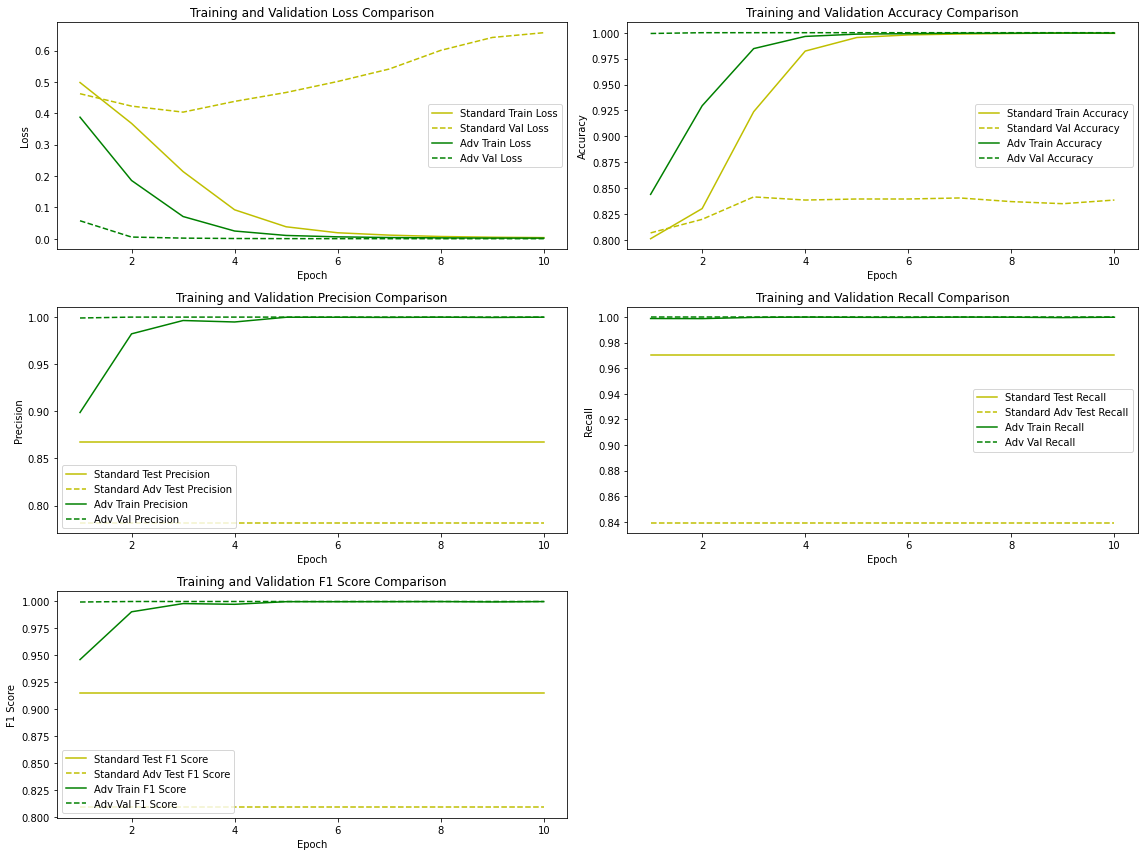

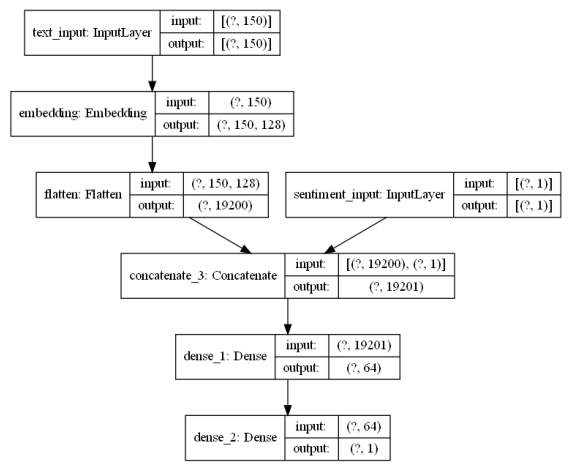

In [4]:
# 绘制对比图表
epochs = range(1, 11)
plt.figure(figsize=(16, 12))

# 绘制常规模型和对抗模型的训练与验证损失
plt.subplot(3, 2, 1)
plt.plot(epochs, history.history['loss'], 'y-', label='Standard Train Loss')
plt.plot(epochs, history.history['val_loss'], 'y--', label='Standard Val Loss')
plt.plot(epochs, adv_history['loss'], 'g-', label='Adv Train Loss')
plt.plot(epochs, adv_history['val_loss'], 'g--', label='Adv Val Loss')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 绘制常规模型和对抗模型的训练与验证准确率
plt.subplot(3, 2, 2)
plt.plot(epochs, history.history['accuracy'], 'y-', label='Standard Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'y--', label='Standard Val Accuracy')
plt.plot(epochs, adv_history['accuracy'], 'g-', label='Adv Train Accuracy')
plt.plot(epochs, adv_history['val_accuracy'], 'g--', label='Adv Val Accuracy')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 绘制常规模型和对抗模型的训练与验证精确率
plt.subplot(3, 2, 3)
plt.plot(epochs, [precision_standard]*len(epochs), 'y-', label='Standard Test Precision')
plt.plot(epochs, [precision_adv_standard]*len(epochs), 'y--', label='Standard Adv Test Precision')
plt.plot(epochs, precision_logs['train'], 'g-', label='Adv Train Precision')
plt.plot(epochs, precision_logs['val'], 'g--', label='Adv Val Precision')
plt.title('Training and Validation Precision Comparison')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()

# 绘制常规模型和对抗模型的训练与验证召回率
plt.subplot(3, 2, 4)
plt.plot(epochs, [recall_standard]*len(epochs), 'y-', label='Standard Test Recall')
plt.plot(epochs, [recall_adv_standard]*len(epochs), 'y--', label='Standard Adv Test Recall')
plt.plot(epochs, recall_logs['train'], 'g-', label='Adv Train Recall')
plt.plot(epochs, recall_logs['val'], 'g--', label='Adv Val Recall')
plt.title('Training and Validation Recall Comparison')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()

# 绘制常规模型和对抗模型的训练与验证F1分数
plt.subplot(3, 2, 5)
plt.plot(epochs, [f1_standard]*len(epochs), 'y-', label='Standard Test F1 Score')
plt.plot(epochs, [f1_adv_standard]*len(epochs), 'y--', label='Standard Adv Test F1 Score')
plt.plot(epochs, f1_logs['train'], 'g-', label='Adv Train F1 Score')
plt.plot(epochs, f1_logs['val'], 'g--', label='Adv Val F1 Score')
plt.title('Training and Validation F1 Score Comparison')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

# 绘制模型架构图并保存为文件
plot_model(model_adv, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

# 使用matplotlib显示图像
image = plt.imread('model_plot.png')
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()